Dado que los archivos se encuentran almacenados en Google Drive. Tenemos que importar lo necesario para montar google drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Llamamos a los archivos desde google Drive, como tambien importamos la libreria pandas para trabajar estos datos. Aqui se tiene que modificar la ruta según sea donde estén almacenados los datos.


In [ ]:
import pandas as pd

# Rutas para los supervisados

#ruta_supervisados_og10  = '/content/drive/MyDrive/Datasets_Tesis/Ton_IoT/Resultados-evaluacion-modelos/OG10_Evaluaciones_sup.csv'
#ruta_supervisados_gen10 = '/content/drive/MyDrive/Datasets_Tesis/Ton_IoT/Resultados-evaluacion-modelos/GEN10_Evaluaciones_sup.csv'

ruta_supervisados_og10  = '/content/drive/MyDrive/Datasets_Tesis/Ton_IoT/Resultados-evaluacion-modelos/OG10_SUP_CV10.csv'
ruta_supervisados_gen10 = '/content/drive/MyDrive/Datasets_Tesis/Ton_IoT/Resultados-evaluacion-modelos/GEN10_SUP_CV10.csv'

#Rutas para los no supervisados

#ruta_nosupervisados_og10  = '/content/drive/MyDrive/Datasets_Tesis/Ton_IoT/Resultados-evaluacion-modelos/OG10_Evaluaciones_no_sup.csv'
#ruta_nosupervisados_gen10 = '/content/drive/MyDrive/Datasets_Tesis/Ton_IoT/Resultados-evaluacion-modelos/GEN10_Evaluaciones_no_sup.csv'

ruta_nosupervisados_og10  = '/content/drive/MyDrive/Datasets_Tesis/Ton_IoT/Resultados-evaluacion-modelos/OG10_unsup_times.csv'
ruta_nosupervisados_gen10 = '/content/drive/MyDrive/Datasets_Tesis/Ton_IoT/Resultados-evaluacion-modelos/GEN10_unsup_times.csv'




#Leer archivos con resultados de modelos supervisados

supervisados_OG10 = pd.read_csv(ruta_supervisados_og10)
supervisados_GEN10 = pd.read_csv(ruta_supervisados_gen10)

# Leer archivos con los resultados de modelos no supervisados

no_supervisados_OG10 = pd.read_csv(ruta_nosupervisados_og10)
no_supervisados_GEN10 = pd.read_csv(ruta_nosupervisados_gen10)



Bloque opcional para verificar la integridad de los datos


In [ ]:
print(supervisados_OG10)
print(no_supervisados_OG10)
print(supervisados_GEN10)
print(no_supervisados_GEN10)

   accuracy_Random Forest  precision_Random Forest  recall_Random Forest  \
0                0.985728                 0.982005              0.986919   
1                0.984980                 0.981141              0.986157   
2                0.985370                 0.981490              0.986680   
3                0.983180                 0.978708              0.984774   
4                0.983895                 0.979627              0.985382   
5                0.985153                 0.981295              0.986391   
6                0.985056                 0.981139              0.986345   
7                0.985088                 0.981271              0.986262   
8                0.984795                 0.980833              0.986088   
9                0.985186                 0.981345              0.986409   

   f1_score_Random Forest  auc_Random Forest  TP_Random Forest  \
0                0.984456           0.997854             31915   
1                0.983643      



---

A partir de los datos obtenidos, generamos gráficos que permiten verificar los resultados obtemidos en cada una de las metricas a lo largo de las 10 evaluaciones. Se hace para ambos tipos de modelos.



---



In [ ]:
import pandas as pd
from scipy.stats import sem
from google.colab import files

modelos_sup = ['Random Forest', 'Decision Tree', 'Naive Bayes']
modelos_nosup = ['Isolation Forest', 'One-Class SVM', 'Local Outlier Factor', 'Elliptic Envelope']
metricas = ['accuracy', 'precision', 'recall', 'f1_score','f1', 'auc','TP','TN','FP','FN','MCC','train_time','predict_time']
estadisticas = []

# No supervisados
for modelo in modelos_nosup:
    for metrica in metricas:
        col = f"{metrica}_{modelo}"
        if col in no_supervisados_OG10.columns and col in no_supervisados_GEN10.columns:
            valores_og = no_supervisados_OG10[col]
            valores_gen = no_supervisados_GEN10[col]

            if metrica in ['TP', 'TN', 'FP', 'FN']:
                estadisticas.append({
                "Tipo": "No Supervisado",
                "Modelo": modelo,
                "Métrica": metrica,
                "Origen": "OG10",
                "Media": int(valores_og.mean()),
                "Error": int(sem(valores_og)),
                "N": len(valores_og)
                 })
                estadisticas.append({
                "Tipo": "No Supervisado",
                "Modelo": modelo,
                "Métrica": metrica,
                "Origen": "GEN10",
                "Media": int(valores_gen.mean()),
                "Error": int(sem(valores_gen)),
                "N": len(valores_gen)
                })

            else:

                estadisticas.append({
                  "Tipo": "No Supervisado",
                  "Modelo": modelo,
                  "Métrica": metrica,
                  "Origen": "ToN_IoT",
                  "Media": valores_og.mean(),
                  "Error": sem(valores_og),
                  "N": len(valores_og)
                })
                estadisticas.append({
                      "Tipo": "No Supervisado",
                      "Modelo": modelo,
                      "Métrica": metrica,
                      "Origen": "Propuesto",
                      "Media": valores_gen.mean(),
                      "Error": sem(valores_gen),
                      "N": len(valores_gen)
                })




# Supervisados
for modelo in modelos_sup:
    for metrica in metricas:
        col = f"{metrica}_{modelo}"
        if col in supervisados_OG10.columns and col in supervisados_GEN10.columns:
            valores_og = supervisados_OG10[col]
            valores_gen = supervisados_GEN10[col]

            if metrica in ['TP', 'TN', 'FP', 'FN']:
                estadisticas.append({
                    "Tipo": "Supervisado",
                    "Modelo": modelo,
                    "Métrica": metrica,
                    "Origen": "ToN_Io",
                    "Media": int(valores_og.mean()),
                    "Error": int(sem(valores_og)),
                    "N": len(valores_og)
                })
                estadisticas.append({
                    "Tipo": "Supervisado",
                    "Modelo": modelo,
                    "Métrica": metrica,
                    "Origen": "Propuesto",
                    "Media": int(valores_gen.mean()),
                    "Error": int(sem(valores_gen)),
                    "N": len(valores_gen)
                })

            else:
                estadisticas.append({
                    "Tipo": "Supervisado",
                    "Modelo": modelo,
                    "Métrica": metrica,
                    "Origen": "ToN_Io",
                    "Media": valores_og.mean(),
                    "Error": valores_og.std(),
                    "N": len(valores_og)
                })
                estadisticas.append({
                    "Tipo": "Supervisado",
                    "Modelo": modelo,
                    "Métrica": metrica,
                    "Origen": "Propuesto",
                    "Media": valores_gen.mean(),
                    "Error": valores_gen.std(),
                    "N": len(valores_gen)
                })

# Guardar y descargar
df_estadisticas = pd.DataFrame(estadisticas)
df_estadisticas.to_csv("estadisticos_modelos_final.csv", index=False)
#files.download("estadisticos_modelos_final.csv")


In [ ]:
pprint(df_estadisticas)

Pretty printing has been turned OFF


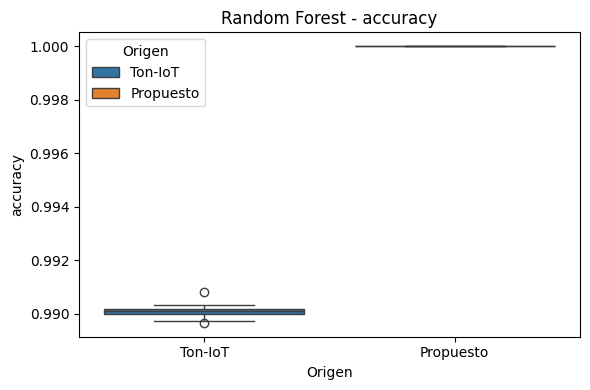

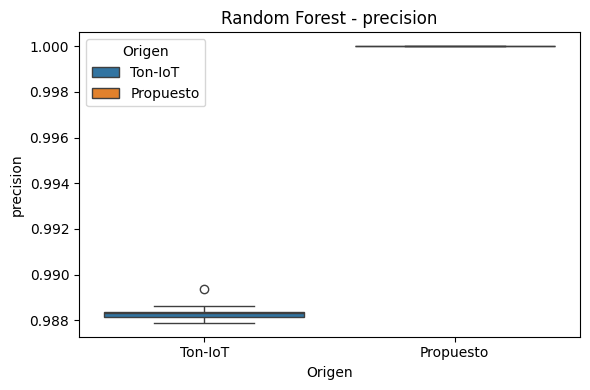

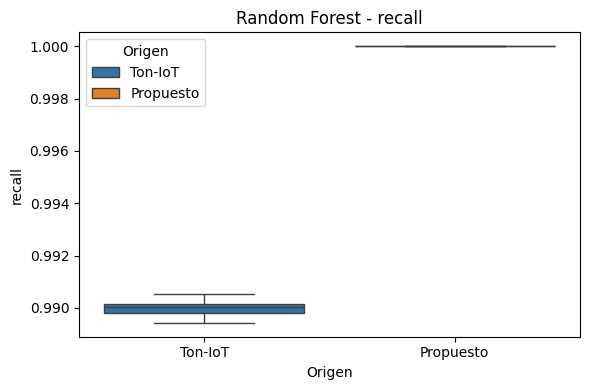

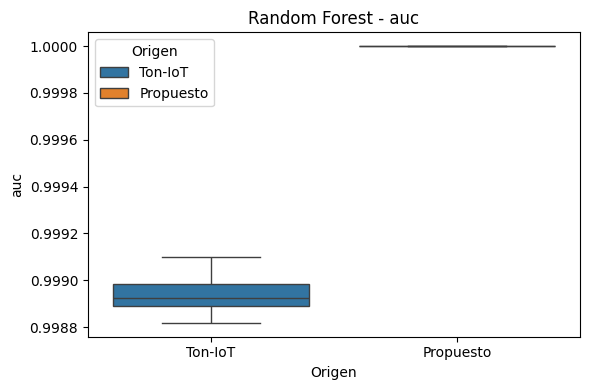

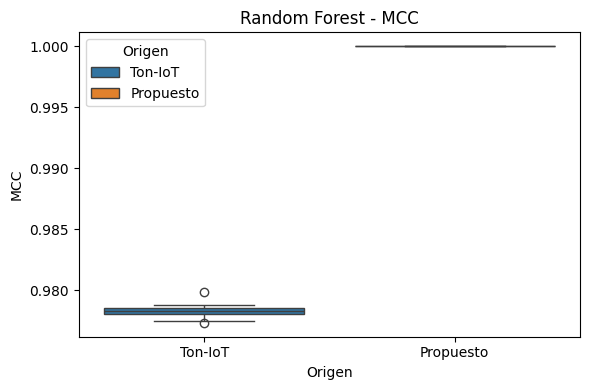

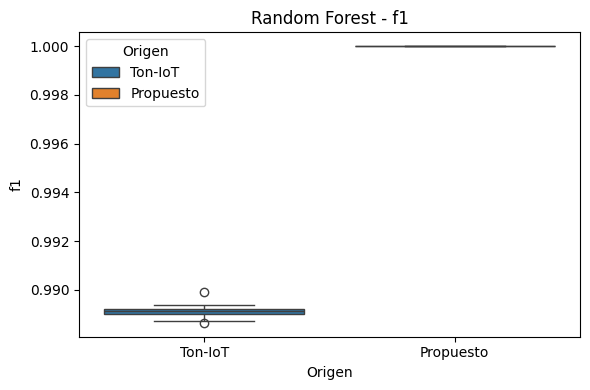

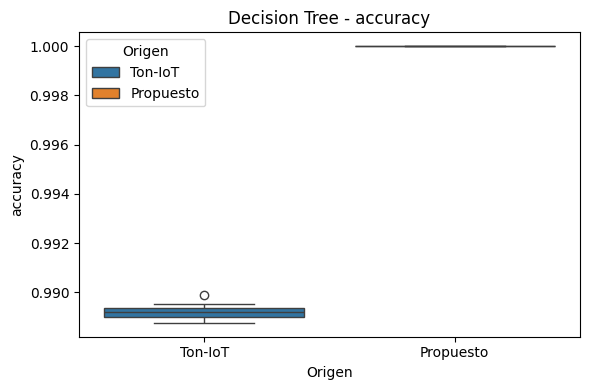

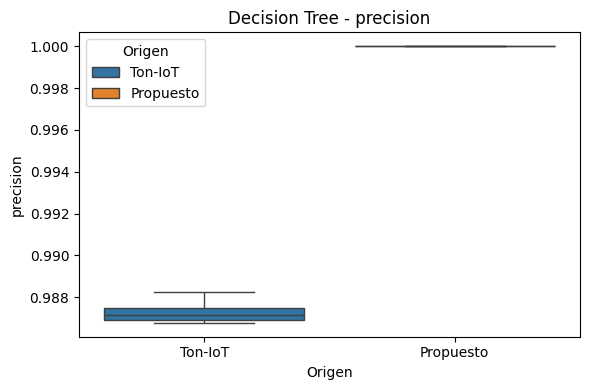

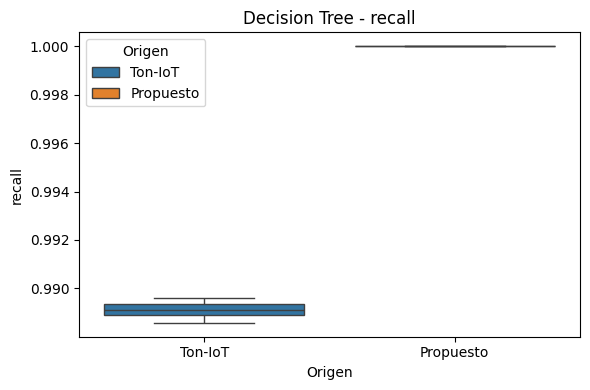

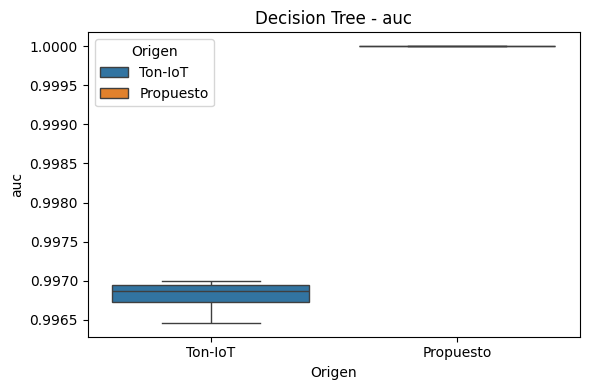

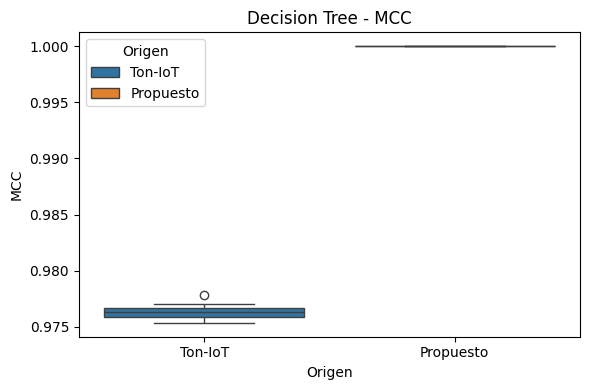

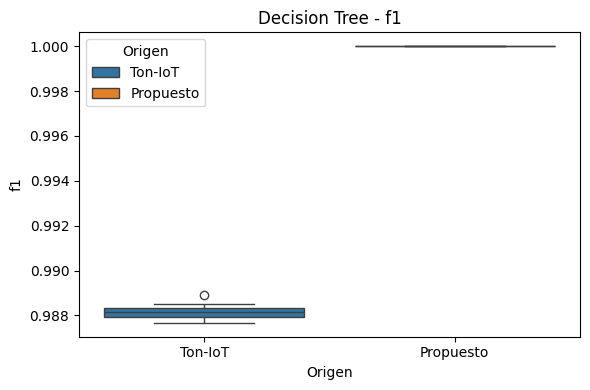

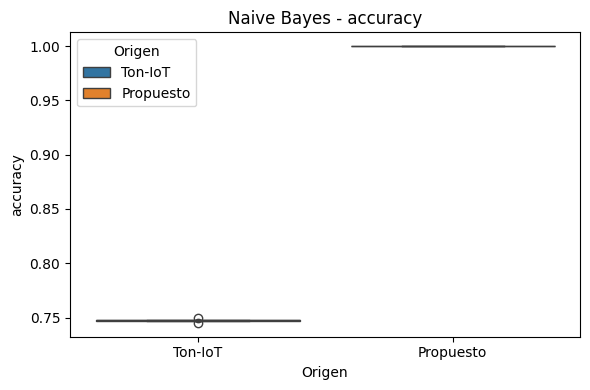

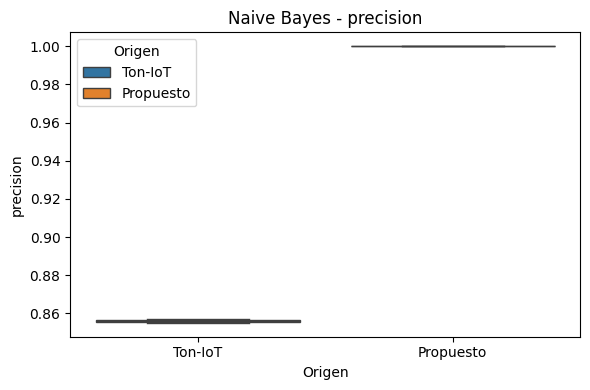

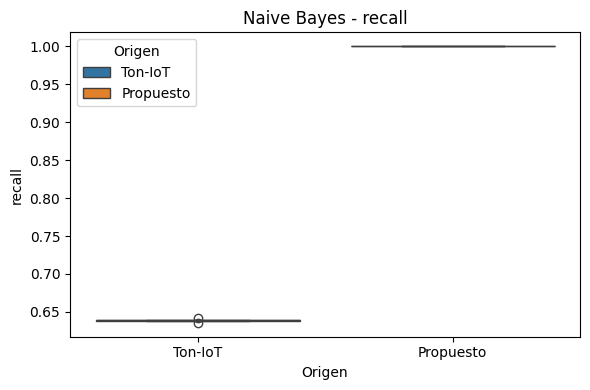

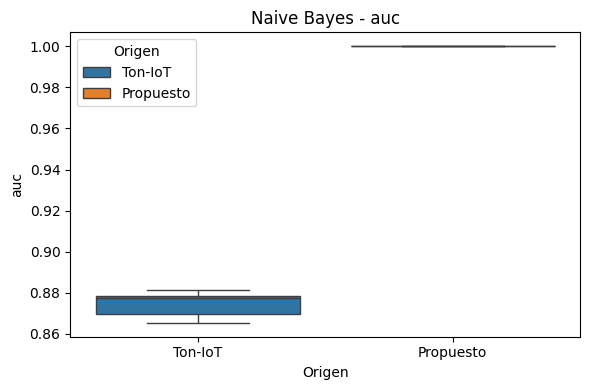

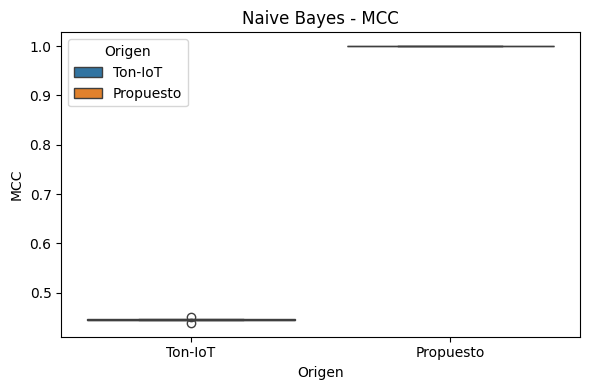

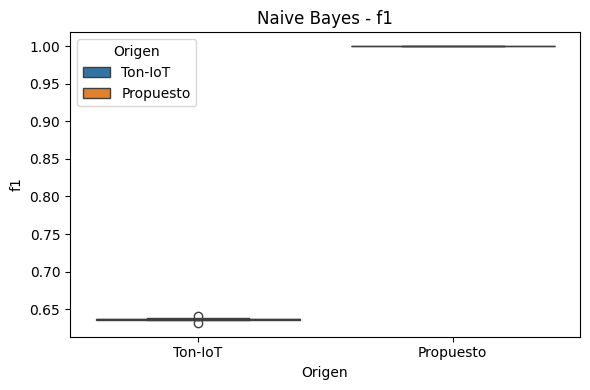

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definir modelos supervisados y métricas
modelos_sup = ['Random Forest', 'Decision Tree', 'Naive Bayes']
metricas = ['accuracy', 'precision', 'recall', 'f1_score', 'auc','MCC','f1']

# Generar gráficos
for modelo in modelos_sup:
    for metrica in metricas:
        col = f"{metrica}_{modelo}"
        if col in supervisados_OG10.columns and col in supervisados_GEN10.columns:
            datos = {
                "Ton-IoT": supervisados_OG10[col],
                "Propuesto": supervisados_GEN10[col]
            }
            df_plot = pd.DataFrame(datos)
            df_plot = df_plot.melt(var_name="Origen", value_name=metrica)

            plt.figure(figsize=(6, 4))
            sns.boxplot(data=df_plot, x="Origen", y=metrica, hue = "Origen", legend=True)
            plt.title(f"{modelo} - {metrica}")
            plt.tight_layout()
            plt.show()


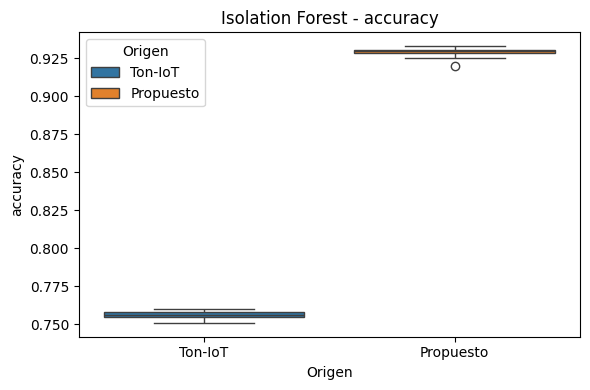

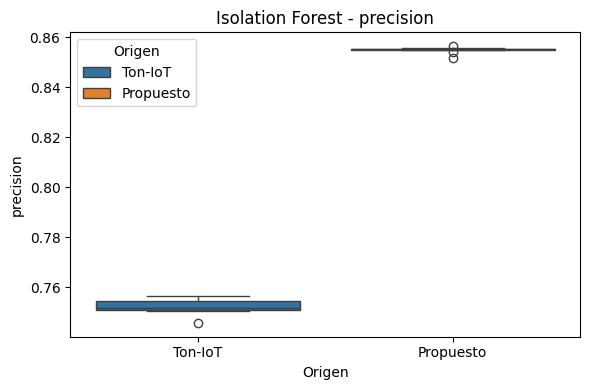

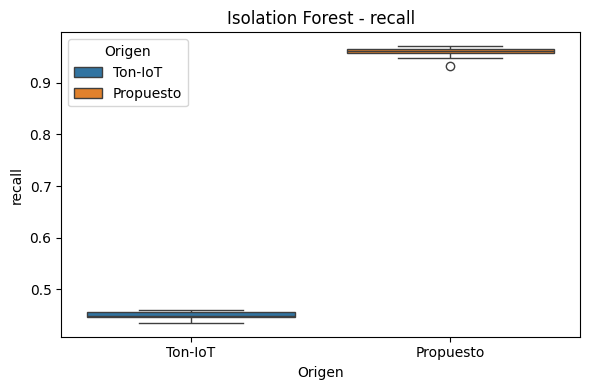

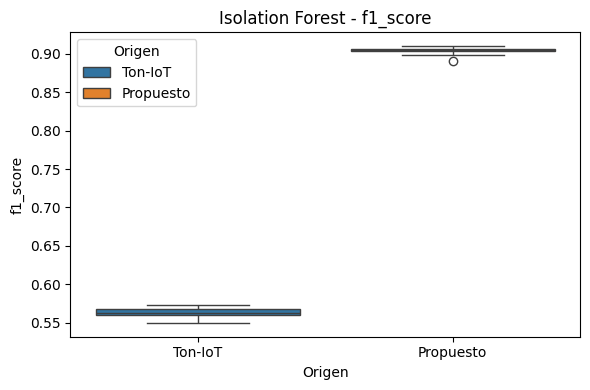

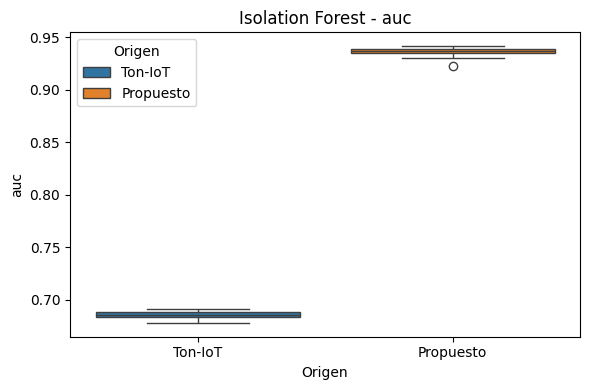

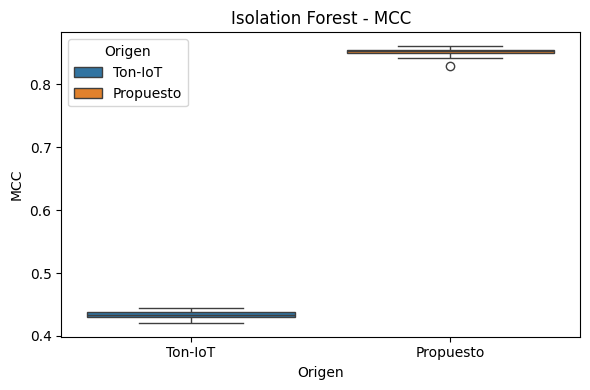

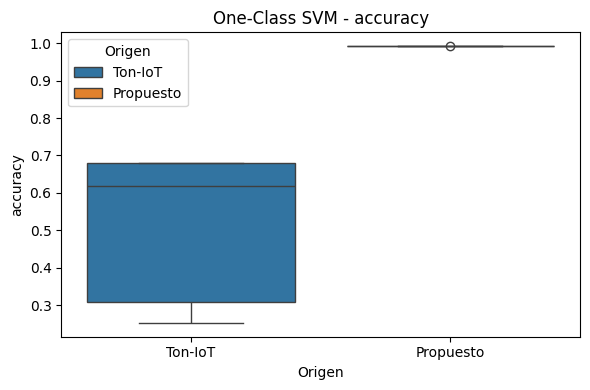

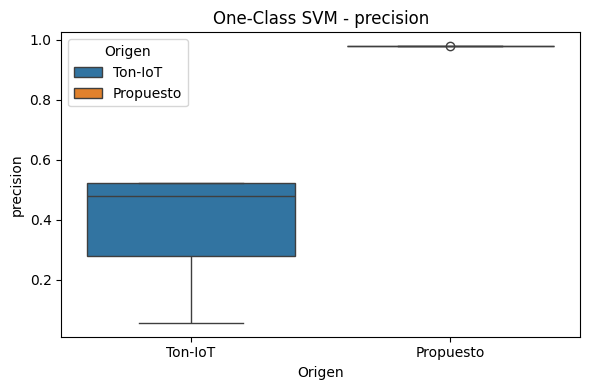

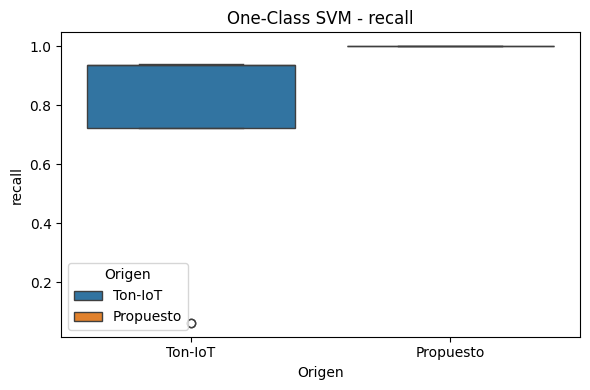

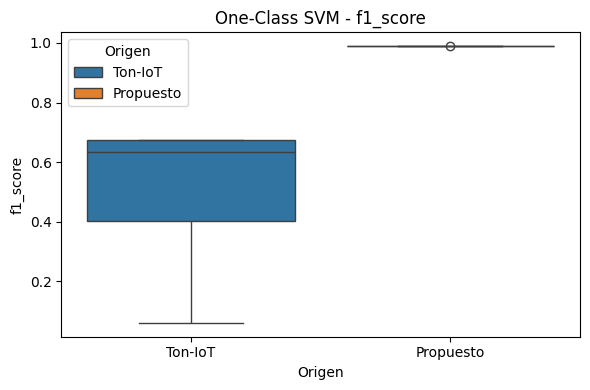

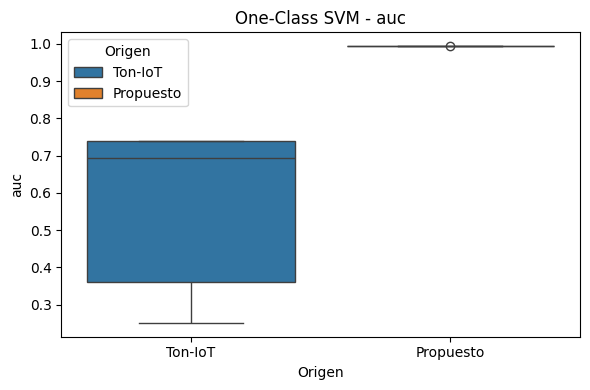

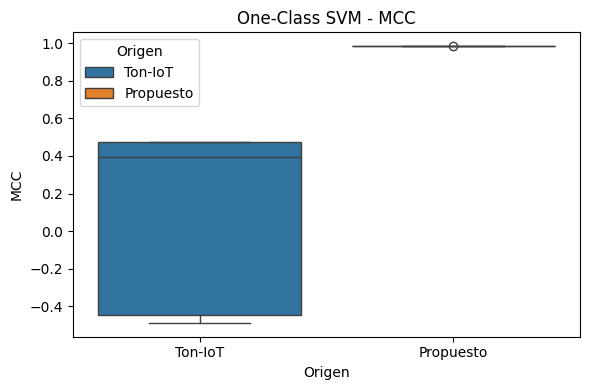

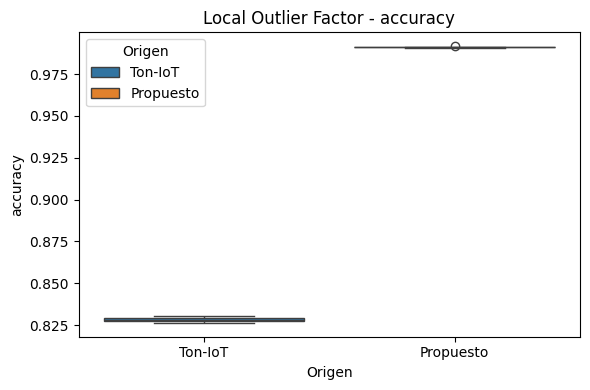

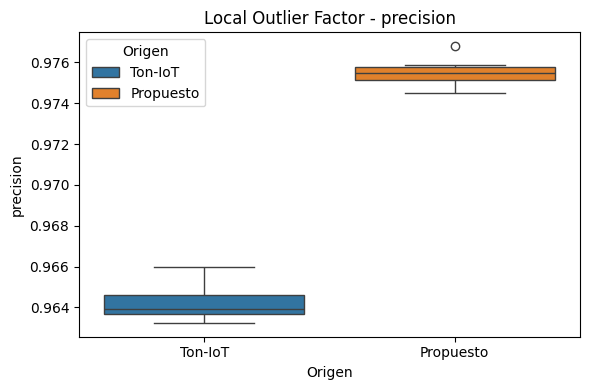

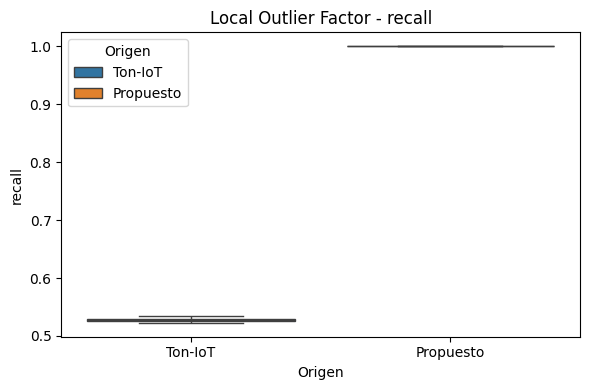

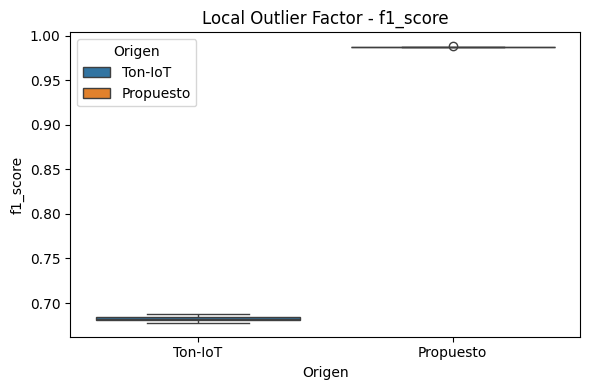

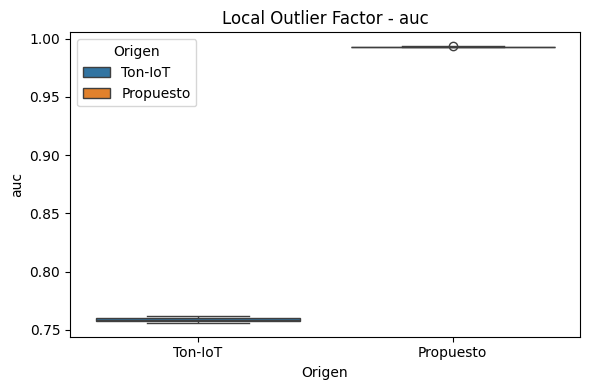

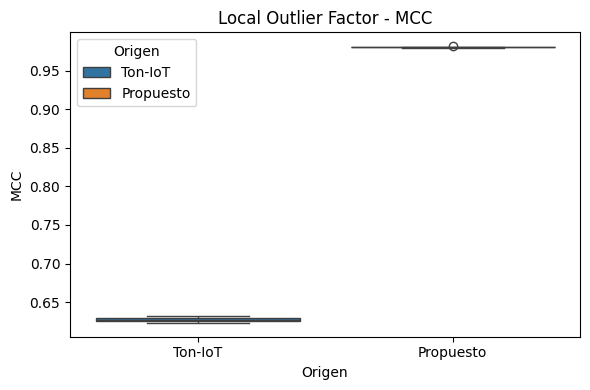

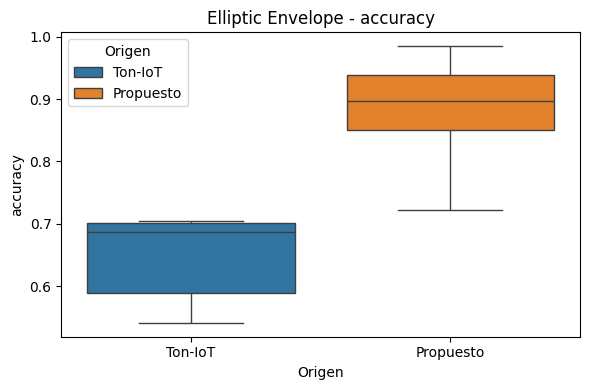

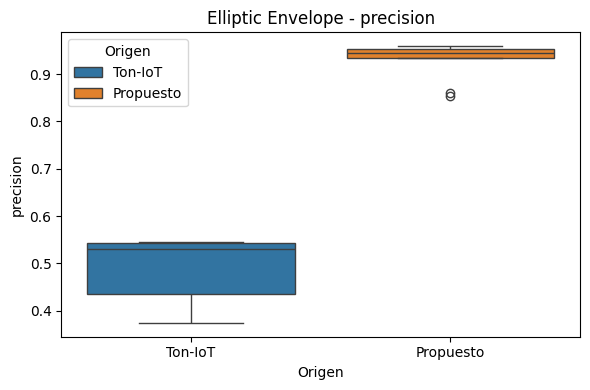

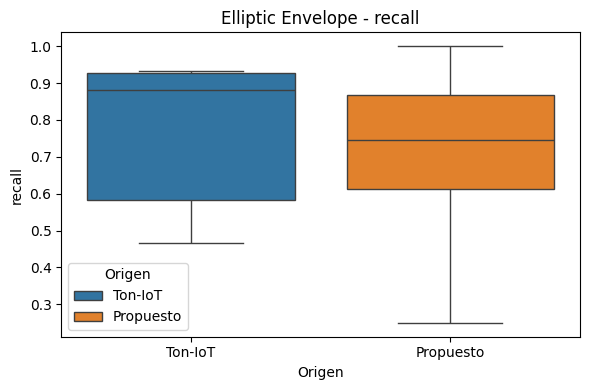

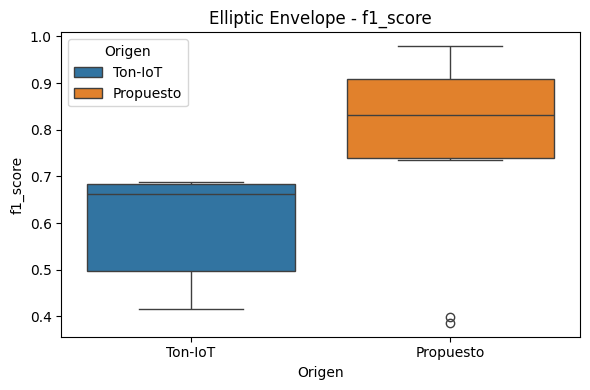

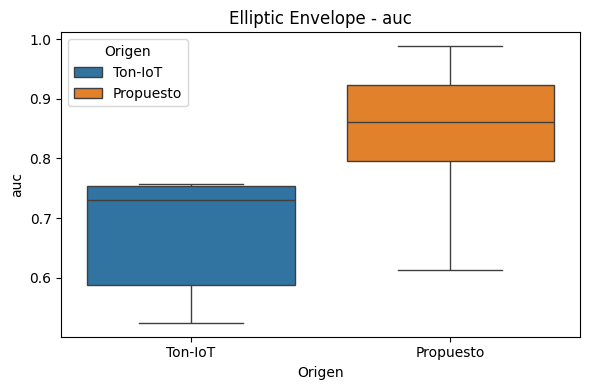

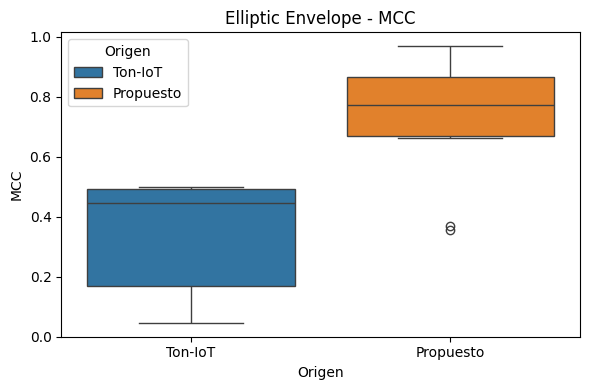

In [ ]:
# Definir modelos no supervisados
modelos_nosup = ['Isolation Forest', 'One-Class SVM', 'Local Outlier Factor', 'Elliptic Envelope']

# Generar gráficos
for modelo in modelos_nosup:
    for metrica in metricas:
        col = f"{metrica}_{modelo}"
        if col in no_supervisados_OG10.columns and col in no_supervisados_GEN10.columns:
            datos = {
                "Ton-IoT": no_supervisados_OG10[col],
                "Propuesto": no_supervisados_GEN10[col]
            }
            df_plot = pd.DataFrame(datos)
            df_plot = df_plot.melt(var_name="Origen", value_name=metrica)

            plt.figure(figsize=(6, 4))
            sns.boxplot(data=df_plot, x="Origen", y=metrica , hue = "Origen", legend=True)
            plt.title(f"{modelo} - {metrica}")
            plt.tight_layout()
            plt.show()




---

Los boxplots son una buena manera de visualizar los datos, sin embargo, una forma mas resumida de visualizar los resultados obtenidos puede ayudar a la comprension visual.

Debido a esto, se grafican los resultados obtenidos por los modelos en cada metrica para ambos conjuntos de datos. Estos resultados pueden ser observados en los dos siguientes bloques, siendo el primero para obtener los graficos para modelos supervisados y el segundo para los modelos no supervisados.


---




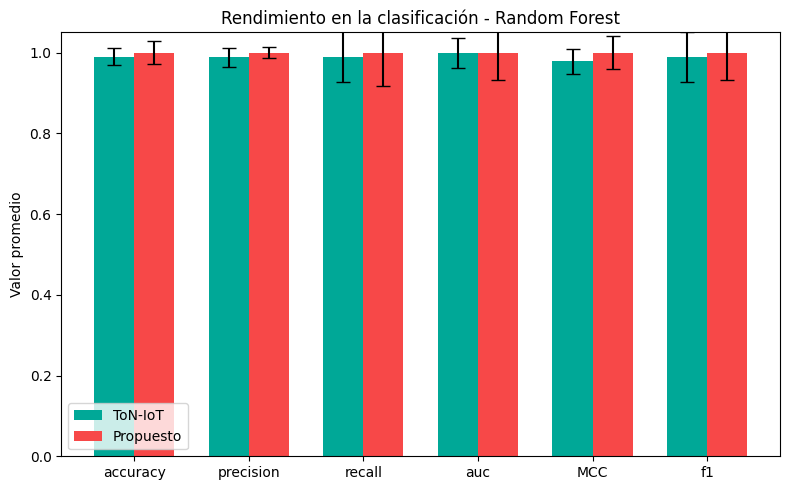

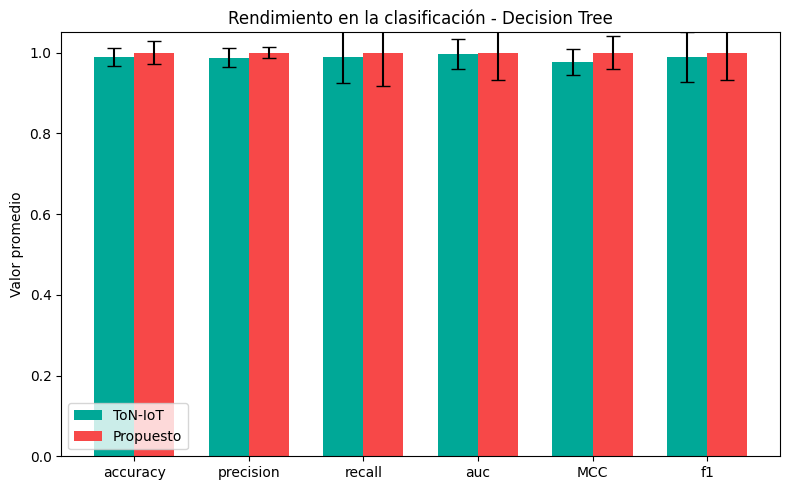

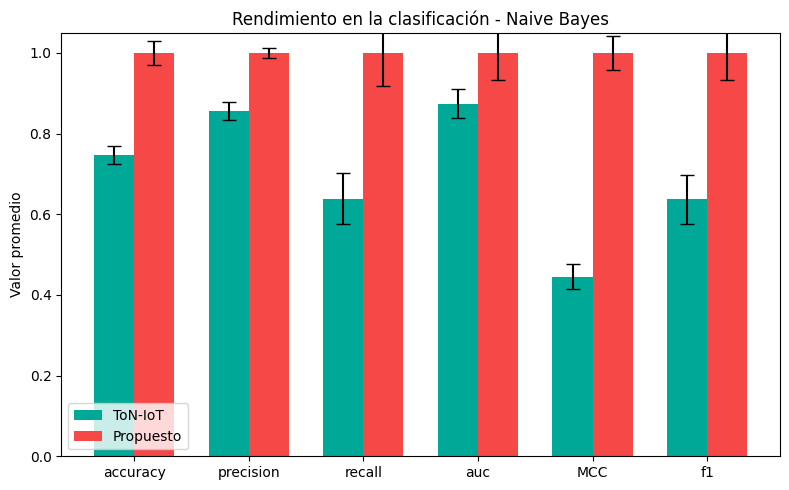

In [ ]:
#Para graficar los modelos  supervisados

import numpy as np


for modelo in modelos_sup:
    medias = []
    stds = []
    labels = []

    for metrica in metricas:
        col = f"{metrica}_{modelo}"
        if col in supervisados_OG10.columns and col in supervisados_GEN10.columns:
            mean_og = supervisados_OG10[col].mean()
            std_og = supervisados_OG10[col].std()
            mean_gen = supervisados_GEN10[col].mean()
            std_gen = supervisados_GEN10[col].std()

            medias.extend([mean_og, mean_gen])
            stds.extend([std_og, std_gen])
            labels.append(metrica)

    # Plot
    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, medias[::2], width, yerr=errores[::2], capsize=5, label='ToN-IoT', color='#00A897')
    plt.bar(x + width/2, medias[1::2], width, yerr=errores[1::2], capsize=5, label='Propuesto', color = '#F74848' )
    plt.ylabel('Valor promedio')
    plt.title(f'Rendimiento en la clasificación - {modelo}')
    plt.xticks(x, labels)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()


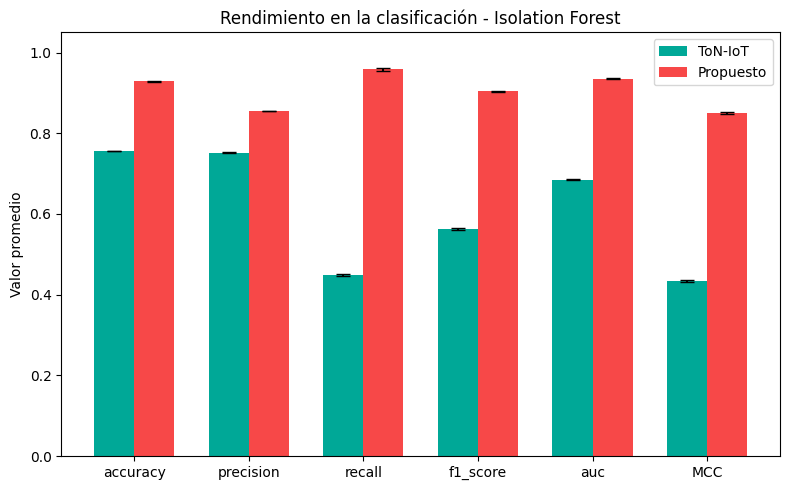

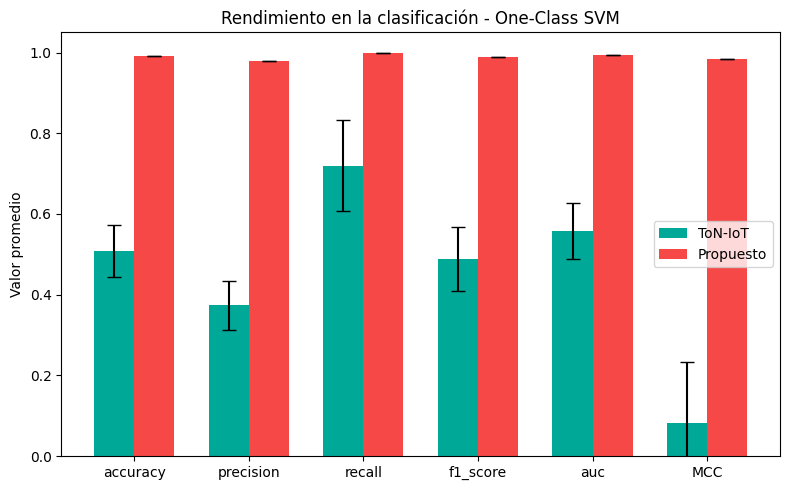

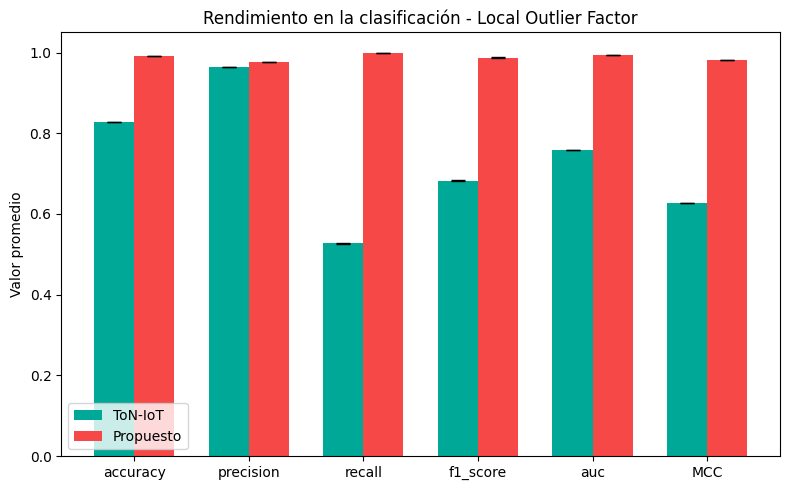

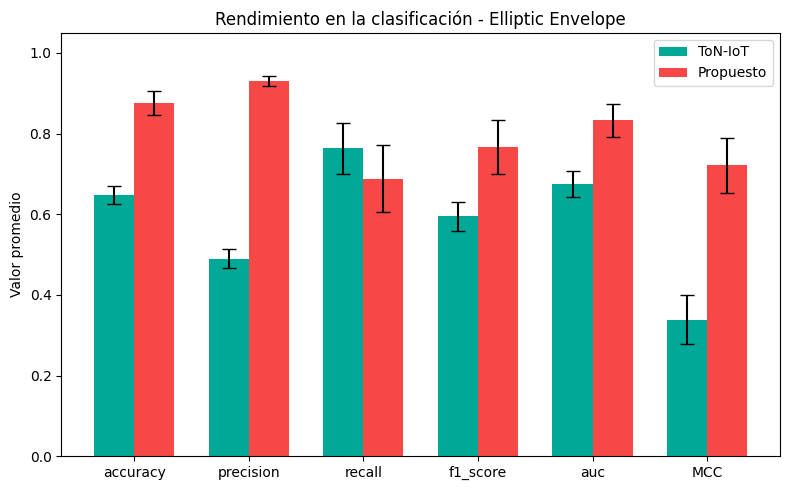

In [ ]:
#Para graficar los modelos no supervisados

from scipy.stats import sem


for modelo in modelos_nosup:
    medias = []
    errores = []
    labels = []

    for metrica in metricas:
        col = f"{metrica}_{modelo}"
        if col in no_supervisados_OG10.columns and col in no_supervisados_GEN10.columns:
            # Calcular medias
            mean_og = no_supervisados_OG10[col].mean()
            mean_gen = no_supervisados_GEN10[col].mean()
            medias.extend([mean_og, mean_gen])

            # Calcular error estándar
            err_og = sem(no_supervisados_OG10[col])
            err_gen = sem(no_supervisados_GEN10[col])

            # Limitar visualmente para no superar 1.0 en la gráfica
            err_og = min(err_og, 1 - mean_og)
            err_gen = min(err_gen, 1 - mean_gen)

            errores.extend([err_og, err_gen])
            labels.append(metrica)

    # Gráfico de barras agrupadas
    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, medias[::2], width, yerr=errores[::2], capsize=5, label='ToN-IoT', color='#00A897')

    plt.bar(x + width/2, medias[1::2], width, yerr=errores[1::2], capsize=5, label='Propuesto', color = '#F74848' )

    plt.ylabel('Valor promedio')
    plt.title(f'Rendimiento en la clasificación - {modelo}')
    plt.xticks(x, labels)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()


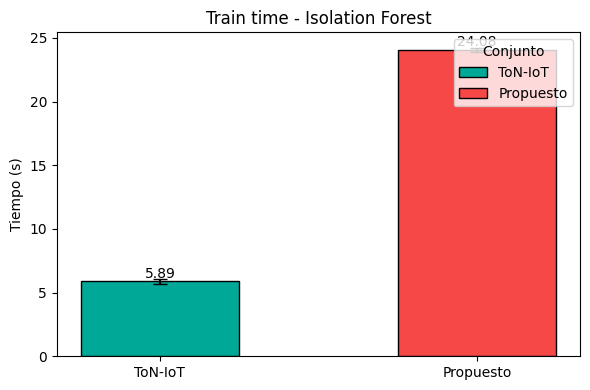

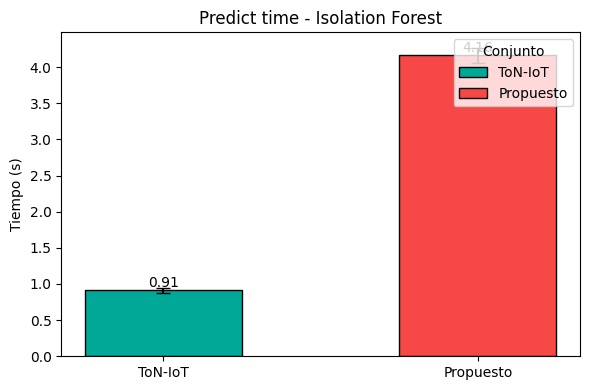

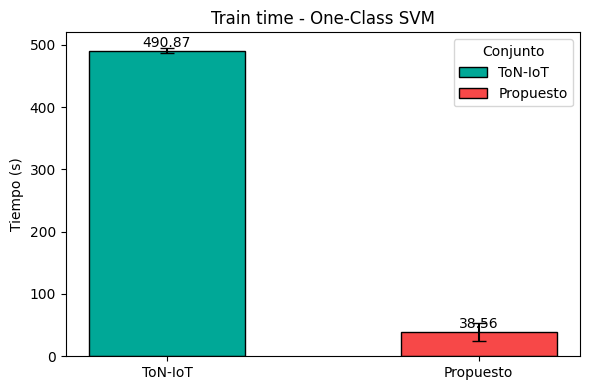

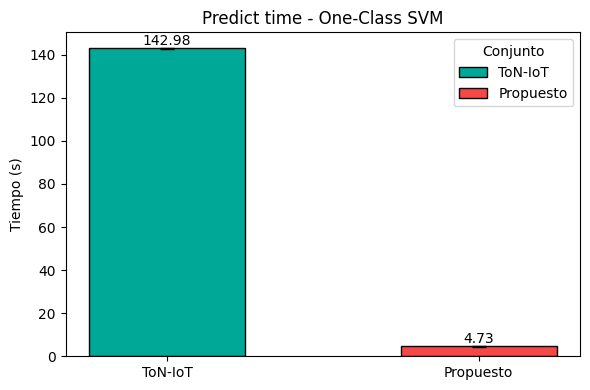

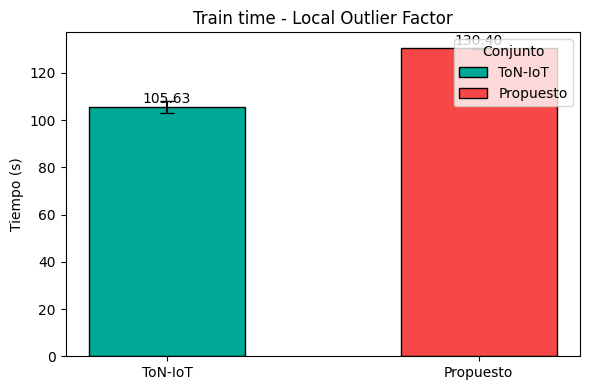

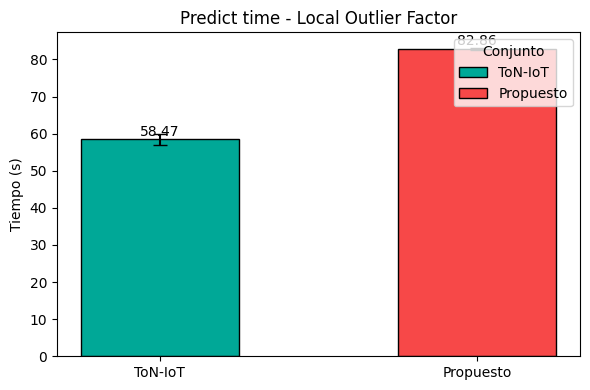

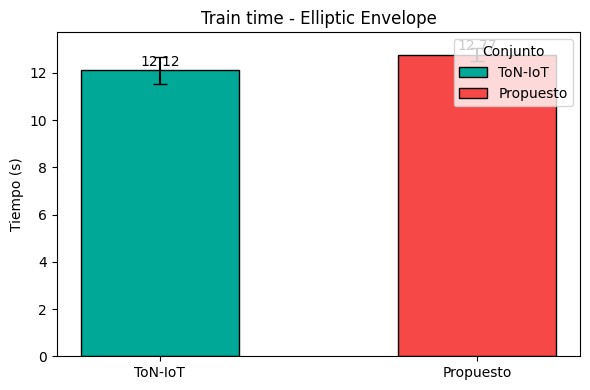

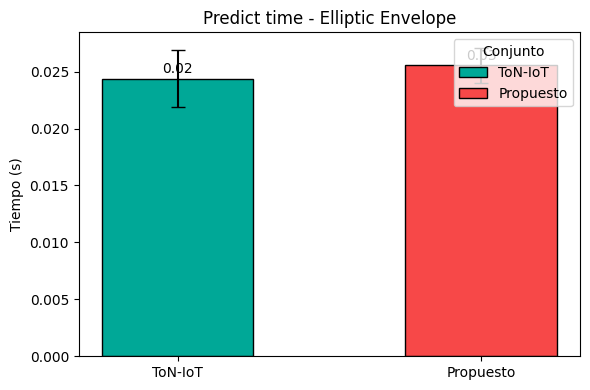

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

metricas_tiempo = ['train_time', 'predict_time']

for modelo in modelos_nosup:
    for metrica in metricas_tiempo:
        col = f"{metrica}_{modelo}"
        if col in no_supervisados_OG10 and col in no_supervisados_GEN10.columns:
            # Calcular medias
            mean_og = no_supervisados_OG10[col].mean()
            mean_gen = no_supervisados_GEN10[col].mean()

            # Calcular error estándar
            err_og = sem(no_supervisados_OG10[col])
            err_gen = sem(no_supervisados_GEN10[col])

            # Preparar datos
            medias = [mean_og, mean_gen]
            errores = [err_og, err_gen]
            grupos = ['ToN-IoT', 'Propuesto']
            colores = ['#00A897', '#F74848']

            # Gráfico de barras
            x = np.arange(len(grupos))
            width = 0.5

            plt.figure(figsize=(6, 4))
            bars = plt.bar(x, medias, width, yerr=errores, capsize=5, color=colores, edgecolor='black')

            # Agregar texto con valores sobre las barras
            for i, bar in enumerate(bars):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(errores)*0.1,
                         f'{medias[i]:.2f}', ha='center', va='bottom', fontsize=10)

            plt.ylabel('Tiempo (s)')
            plt.title(f'{metrica.replace("_", " ").capitalize()} - {modelo}')
            plt.xticks(x, grupos)
            plt.tight_layout()

            # Leyenda
            plt.legend(bars, grupos, title='Conjunto', loc='upper right')
            plt.show()



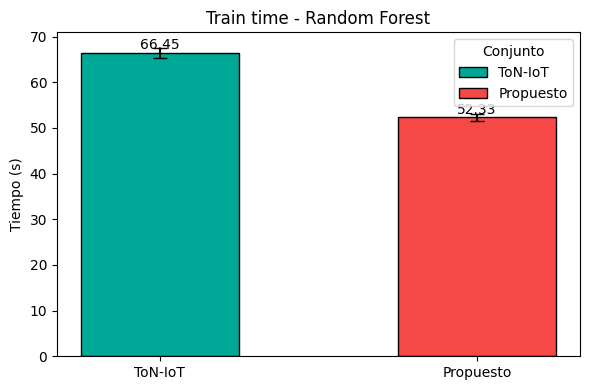

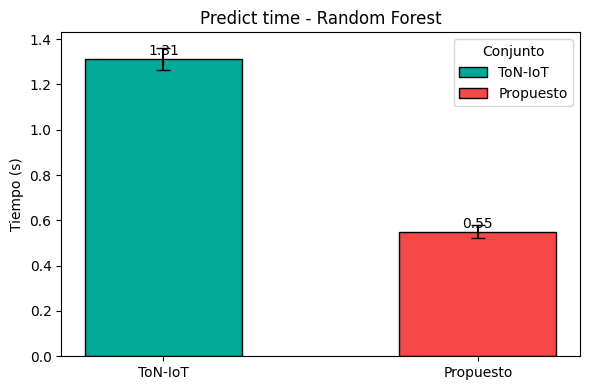

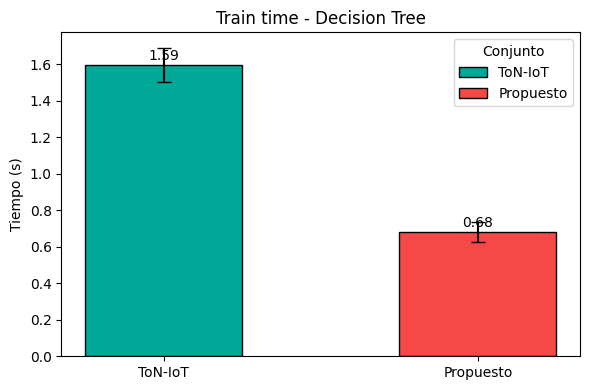

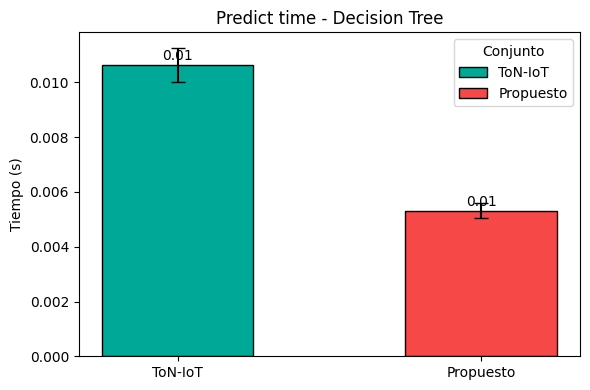

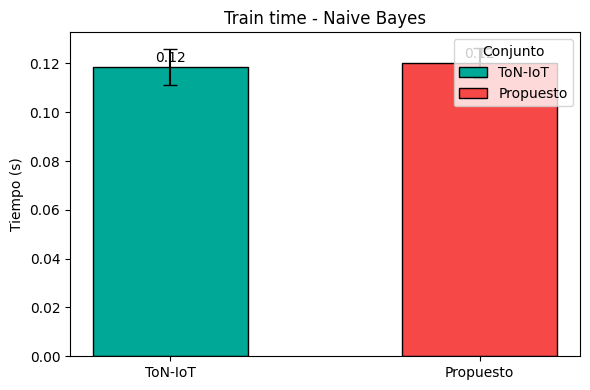

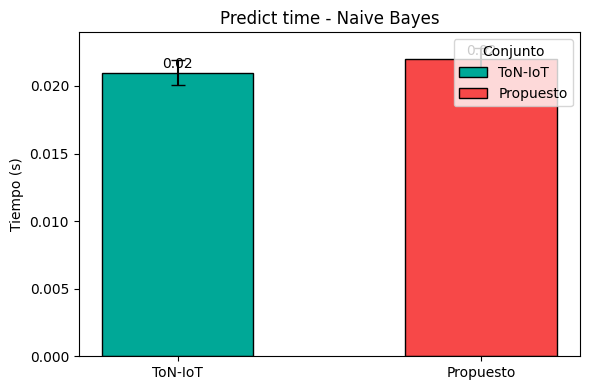

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

metricas_tiempo = ['train_time', 'predict_time']

for modelo in modelos_sup:
    for metrica in metricas_tiempo:
        col = f"{metrica}_{modelo}"
        if col in supervisados_OG10.columns and col in supervisados_GEN10.columns:
            # Calcular medias
            mean_og = supervisados_OG10[col].mean()
            mean_gen = supervisados_GEN10[col].mean()

            # Calcular error estándar
            err_og = sem(supervisados_OG10[col])
            err_gen = sem(supervisados_GEN10[col])

            # Preparar datos
            medias = [mean_og, mean_gen]
            errores = [err_og, err_gen]
            grupos = ['ToN-IoT', 'Propuesto']
            colores = ['#00A897', '#F74848']

            # Gráfico de barras
            x = np.arange(len(grupos))
            width = 0.5

            plt.figure(figsize=(6, 4))
            bars = plt.bar(x, medias, width, yerr=errores, capsize=5, color=colores, edgecolor='black')

            # Agregar texto con valores sobre las barras
            for i, bar in enumerate(bars):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(errores)*0.1,
                         f'{medias[i]:.2f}', ha='center', va='bottom', fontsize=10)

            plt.ylabel('Tiempo (s)')
            plt.title(f'{metrica.replace("_", " ").capitalize()} - {modelo}')
            plt.xticks(x, grupos)
            plt.tight_layout()

            # Leyenda
            plt.legend(bars, grupos, title='Conjunto', loc='upper right')
            plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def graficar_por_metrica(metrica, modelos, df_og, df_gen, tipo='Supervisado', mostrar=True):
    """
    Genera un gráfico de barras comparando ToN-IoT y Propuesto
    para una métrica específica en todos los modelos de un tipo.
    Retorna los promedios y desviaciones para usar en el gráfico combinado.
    """
    medias_og = []
    medias_gen = []
    stds_og = []
    stds_gen = []
    labels = []

    # Recolectar estadísticas para cada modelo
    for modelo in modelos:
        col = f"{metrica}_{modelo}"
        if col in df_og.columns and col in df_gen.columns:
            mean_og = df_og[col].mean()
            std_og = df_og[col].std()
            mean_gen = df_gen[col].mean()
            std_gen = df_gen[col].std()

            medias_og.append(mean_og)
            stds_og.append(std_og)
            medias_gen.append(mean_gen)
            stds_gen.append(std_gen)
            labels.append(modelo)

    if not labels:
        print(f"No se encontraron columnas para la métrica '{metrica}' en los modelos de tipo {tipo}.")
        return None

    if mostrar:
        # Configuración del gráfico
        x = np.arange(len(labels))
        width = 0.35

        plt.figure(figsize=(9, 5))
        plt.bar(x - width/2, medias_og, width, yerr=stds_og, capsize=5, label='ToN-IoT', color='#00A897')
        plt.bar(x + width/2, medias_gen, width, yerr=stds_gen, capsize=5, label='Propuesto', color='#F74848')

        plt.ylabel('Valor promedio')
        plt.title(f'{tipo}: comparación por métrica - {metrica}')
        plt.xticks(x, labels, rotation=20)
        plt.ylim(0, 1.05)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return labels, medias_og, stds_og, medias_gen, stds_gen


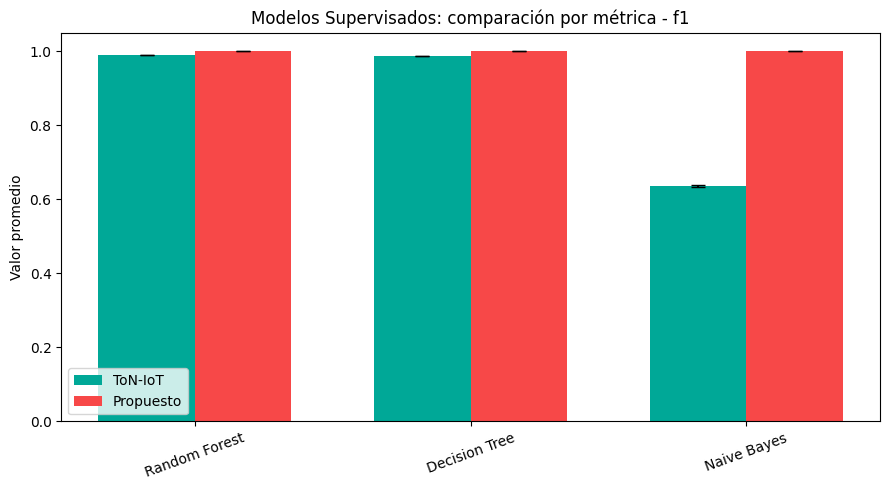

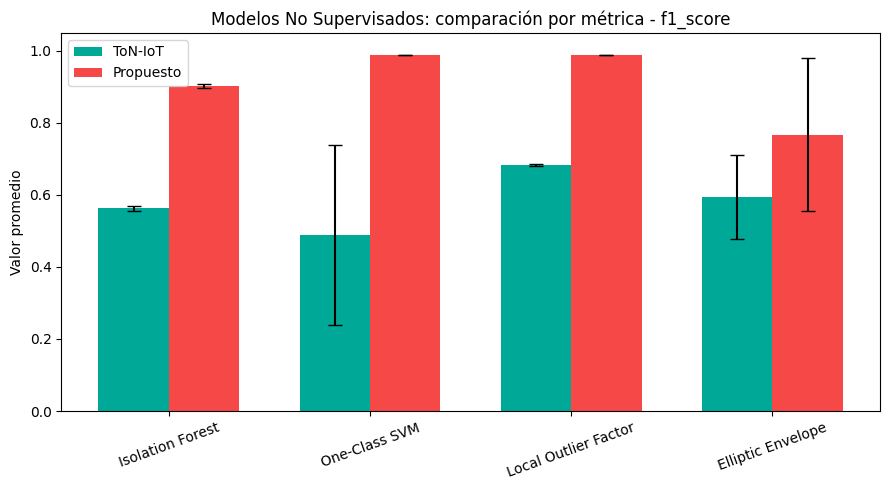

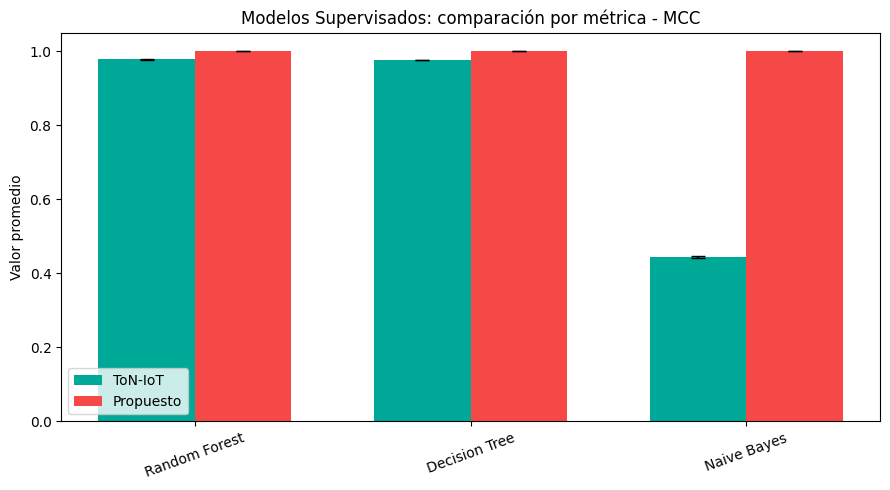

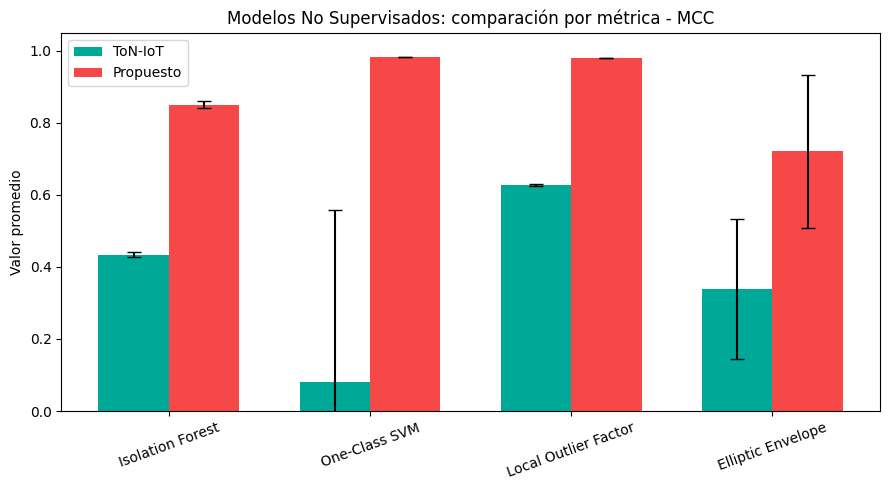

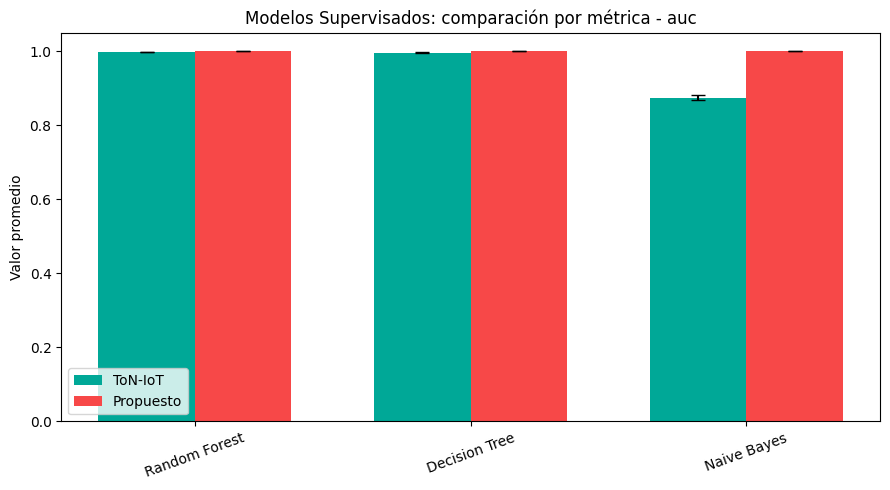

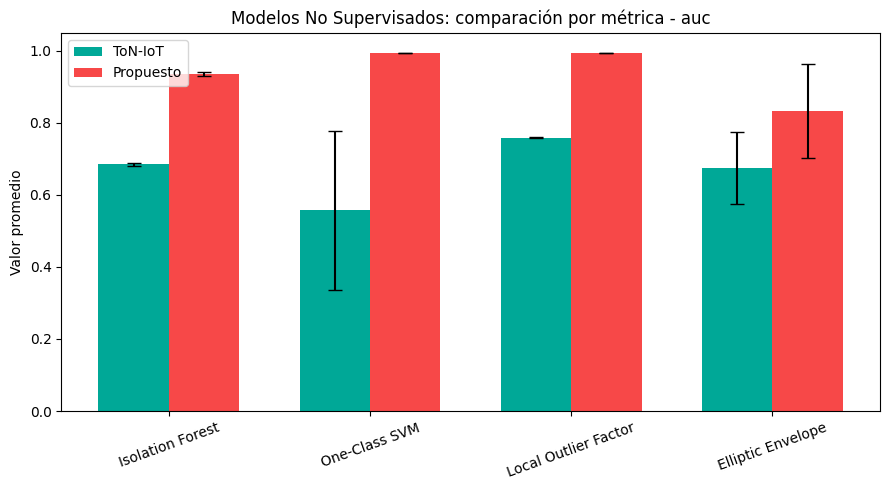

(['Isolation Forest',
  'One-Class SVM',
  'Local Outlier Factor',
  'Elliptic Envelope'],
 [np.float64(0.6850551154992549),
  np.float64(0.5571697963238947),
  np.float64(0.7587470131644312),
  np.float64(0.6750554806259313)],
 [0.0038343768266530334,
  0.22123210311494762,
  0.001953753320918902,
  0.09984959062913235],
 [np.float64(0.9355374056135121),
  np.float64(0.9941058333333332),
  np.float64(0.9932583333333336),
  np.float64(0.8327450037257824)],
 [0.005428420838063028,
  5.444019257771845e-05,
  0.0001731605263945642,
  0.13073888207093315])

In [ ]:
# Gráfico solo para los modelos supervisados
graficar_por_metrica(
    metrica='f1',
    modelos=modelos_sup,
    df_og=supervisados_OG10,
    df_gen=supervisados_GEN10,
    tipo='Modelos Supervisados'
)

# Gráfico solo para los modelos no supervisados
graficar_por_metrica(
    metrica='f1_score',
    modelos=modelos_nosup,
    df_og=no_supervisados_OG10,
    df_gen=no_supervisados_GEN10,
    tipo='Modelos No Supervisados'
)

# Gráfico solo para los modelos supervisados
graficar_por_metrica(
    metrica='MCC',
    modelos=modelos_sup,
    df_og=supervisados_OG10,
    df_gen=supervisados_GEN10,
    tipo='Modelos Supervisados'
)

# Gráfico solo para los modelos no supervisados
graficar_por_metrica(
    metrica='MCC',
    modelos=modelos_nosup,
    df_og=no_supervisados_OG10,
    df_gen=no_supervisados_GEN10,
    tipo='Modelos No Supervisados'
)

# Gráfico solo para los modelos supervisados
graficar_por_metrica(
    metrica='auc',
    modelos=modelos_sup,
    df_og=supervisados_OG10,
    df_gen=supervisados_GEN10,
    tipo='Modelos Supervisados'
)

# Gráfico solo para los modelos no supervisados
graficar_por_metrica(
    metrica='auc',
    modelos=modelos_nosup,
    df_og=no_supervisados_OG10,
    df_gen=no_supervisados_GEN10,
    tipo='Modelos No Supervisados'
)


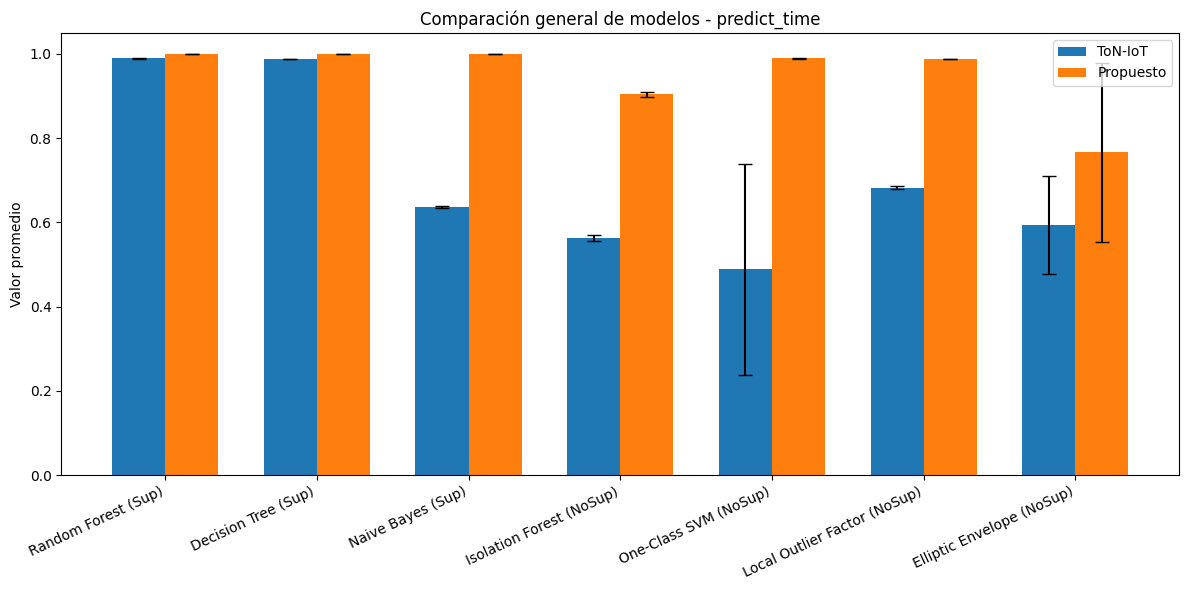

In [ ]:
# Obtener datos de ambos tipos sin mostrar gráficos individuales
sup_labels, sup_og, sup_std_og, sup_gen, sup_std_gen = graficar_por_metrica(
    metrica='f1',
    modelos=modelos_sup,
    df_og=supervisados_OG10,
    df_gen=supervisados_GEN10,
    tipo='Supervisados',
    mostrar=False
)

nosup_labels, nosup_og, nosup_std_og, nosup_gen, nosup_std_gen = graficar_por_metrica(
    metrica='f1_score',
    modelos=modelos_nosup,
    df_og=no_supervisados_OG10,
    df_gen=no_supervisados_GEN10,
    tipo='No Supervisados',
    mostrar=False
)

# Unir todos los datos
labels = [f"{lbl} (Sup)" for lbl in sup_labels] + [f"{lbl} (NoSup)" for lbl in nosup_labels]
medias_og = sup_og + nosup_og
stds_og = sup_std_og + nosup_std_og
medias_gen = sup_gen + nosup_gen
stds_gen = sup_std_gen + nosup_std_gen

# Graficar combinado
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, medias_og, width, yerr=stds_og, capsize=5, label='ToN-IoT', color='#1f77b4')
plt.bar(x + width/2, medias_gen, width, yerr=stds_gen, capsize=5, label='Propuesto', color='#ff7f0e')

plt.ylabel('Valor promedio')
plt.title(f'Comparación general de modelos - {metrica}')
plt.xticks(x, labels, rotation=25, ha='right')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


metricas = 'train_time','predict_time'



---

Una vez realizado los graficos, y dado que la estadística descriptiva no es suficiente para confirmar una hipotesis, hacemos uso de la estadística inferencial.

Dado que se buscan comparar 10 resultados obtenidos mediante las evaluaciones de modelos en distintos conjuntos de datos, se necesita verificar en primera instancia si las muestras pareadas siguen distribuciones del tipo normal. Esto se hace para determinar cual es la prueba estadística que tendrá que ser aplicada.

Para realizar esta tarea, ocupamos la prueba de Shapiro Wilk en cada una de las metricas de cada modelo.


---



In [ ]:
from scipy.stats import shapiro

metricas = ['accuracy', 'precision', 'recall', 'f1_score', 'auc','MCC','train_time', 'predict_time']

# Lista para guardar resultados
normalidad = []

# Función para evaluar normalidad de las diferencias
def evaluar_normalidad(df_og, df_gen, modelo, metrica, tipo_modelo):
    col = f"{metrica}_{modelo}"
    if col in df_og.columns and col in df_gen.columns:
        try:
            dif = df_gen[col] - df_og[col]
            stat, p = shapiro(dif)
            normal = "Sí" if p >= 0.05 else "No"
            normalidad.append({
                "Tipo de modelo": tipo_modelo,
                "Modelo": modelo,
                "Métrica": metrica,
                "p-valor Shapiro-Wilk": round(p, 5),
                "¿Distribución Normal?": normal
            })
        except Exception as e:
            normalidad.append({
                "Tipo de modelo": tipo_modelo,
                "Modelo": modelo,
                "Métrica": metrica,
                "p-valor Shapiro-Wilk": None,
                "¿Distribución Normal?": f"Error: {e}"
            })

# Evaluar supervisados
for modelo in modelos_sup:
    for metrica in metricas:
        evaluar_normalidad(supervisados_OG10, supervisados_GEN10, modelo, metrica, "Supervisado")

# Evaluar no supervisados
for modelo in modelos_nosup:
    for metrica in metricas:
        evaluar_normalidad(no_supervisados_OG10, no_supervisados_GEN10, modelo, metrica, "No Supervisado")

# Crear DataFrame de resultados
df_normalidad = pd.DataFrame(normalidad)

# Mostrar tabla
print("\n=== Resultados de la prueba de normalidad (Shapiro-Wilk) ===")
print(df_normalidad)

# (Opcional) Guardar a CSV
df_normalidad.to_csv("normalidad_shapiro.csv", index=False)
files.download("normalidad_shapiro.csv")


=== Resultados de la prueba de normalidad (Shapiro-Wilk) ===
    Tipo de modelo                Modelo       Métrica  p-valor Shapiro-Wilk  \
0      Supervisado         Random Forest      accuracy               0.33357   
1      Supervisado         Random Forest     precision               0.05086   
2      Supervisado         Random Forest        recall               0.90205   
3      Supervisado         Random Forest           auc               0.77084   
4      Supervisado         Random Forest           MCC               0.35296   
5      Supervisado         Random Forest    train_time               0.28170   
6      Supervisado         Random Forest  predict_time               0.06430   
7      Supervisado         Decision Tree      accuracy               0.79013   
8      Supervisado         Decision Tree     precision               0.17765   
9      Supervisado         Decision Tree        recall               0.98604   
10     Supervisado         Decision Tree           auc    

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


---

Habiendo verificado la normalidad de las distribuciones en cada una de las metricas, aplicamos las pruebas T-Test para aquellos que si siguen una distribución normal y la prueba de wilcoxon para aquellas distribuciones que no poseen una forma normal. El siguiente bloque igualmente considera la aplicación de una prueba Post-Hoc del tipo Bonferroni-Holm para corregir los errores del Tipo 1


---

In [ ]:
from scipy.stats import wilcoxon, ttest_rel

alpha = 0.05

# Resultado acumulado
resultados_finales = []
metricas = ['accuracy', 'precision', 'recall', 'f1_score', 'auc','MCC','train_time','predict_time']

# Ejecutar prueba adaptativa según normalidad
def prueba_adaptativa(df_og, df_gen, modelo, metrica, tipo_modelo):
    col = f"{metrica}_{modelo}"
    if col in df_og.columns and col in df_gen.columns:
        try:
            dif = df_gen[col] - df_og[col]
            p_shapiro = shapiro(dif).pvalue
            normal = p_shapiro >= 0.05

            if normal:
                try:
                    stat, p = ttest_rel(df_og[col], df_gen[col])
                    if pd.isna(p):
                        raise ValueError("NaN en t-test, usando Wilcoxon.")
                    prueba = "t-test pareado"
                except:
                    stat, p = wilcoxon(df_og[col], df_gen[col])
                    prueba = "Wilcoxon (fallback)"
            else:
                stat, p = wilcoxon(df_og[col], df_gen[col])
                prueba = "Wilcoxon"

            resultados_finales.append({
                "Tipo de modelo": tipo_modelo,
                "Modelo": modelo,
                "Métrica": metrica,
                "Prueba aplicada": prueba,
                "p-valor": round(p, 5)
            })
        except Exception as e:
            resultados_finales.append({
                "Tipo de modelo": tipo_modelo,
                "Modelo": modelo,
                "Métrica": metrica,
                "Prueba aplicada": "Error",
                "p-valor": None
            })

# Aplicar a todos los modelos
for modelo in modelos_sup:
    for metrica in metricas:
        prueba_adaptativa(supervisados_OG10, supervisados_GEN10, modelo, metrica, "Supervisado")

for modelo in modelos_nosup:
    for metrica in metricas:
        prueba_adaptativa(no_supervisados_OG10, no_supervisados_GEN10, modelo, metrica, "No Supervisado")

# Crear DataFrame
df_pruebas = pd.DataFrame(resultados_finales)



---

Los siguientes bloques son para mostrar los resultados y guardarlos en archivos CSV, para no requerir de nuevas ejecuciones del script para acceder a ellos nuevamente.

---

In [ ]:
print(df_pruebas)

    Tipo de modelo                Modelo       Métrica Prueba aplicada  \
0      Supervisado         Random Forest      accuracy  t-test pareado   
1      Supervisado         Random Forest     precision  t-test pareado   
2      Supervisado         Random Forest        recall  t-test pareado   
3      Supervisado         Random Forest      f1_score  t-test pareado   
4      Supervisado         Random Forest           auc  t-test pareado   
5      Supervisado         Random Forest           MCC  t-test pareado   
6      Supervisado         Random Forest    train_time  t-test pareado   
7      Supervisado         Random Forest  predict_time  t-test pareado   
8      Supervisado         Decision Tree      accuracy  t-test pareado   
9      Supervisado         Decision Tree     precision  t-test pareado   
10     Supervisado         Decision Tree        recall  t-test pareado   
11     Supervisado         Decision Tree      f1_score  t-test pareado   
12     Supervisado         Decision Tr

In [ ]:
df_pruebas.to_csv("resultados_finales.csv", index=False)
files.download("resultados_finales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ------------------------
# Aplicar Holm-Bonferroni
# ------------------------
df_validos = df_pruebas[df_pruebas["p-valor"].notnull()].copy()
df_validos = df_validos.sort_values("p-valor").reset_index()

rechazadas = []
for i, (_, fila) in enumerate(df_validos.iterrows()):
    k = len(df_validos) - i
    if fila["p-valor"] < alpha / k:
        rechazadas.append(fila["index"])
    else:
        break

df_pruebas["Significativo (Holm-Bonferroni)"] = df_pruebas.index.map(
    lambda i: "Sí" if i in rechazadas else "No"
)


# (Opcional) Guardar a Drive
df_pruebas.to_csv("/content/drive/MyDrive/resultados_finales_holm.csv", index=False)

csv_path = "/content/drive/MyDrive/resultados_finales_holm.csv"
# Descargar CSV
from google.colab import files
files.download(csv_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>